# 07 监控与数据漂移：模型会变老

> 前置：`05-evaluation-error-analysis`、`03-probability`（分布）。
> 目标：理解上线后模型变差的两种原因——**数据漂移**（世界变了）与**概念漂移**（规律变了）——并实现 PSI 检测与重训触发。

## 两种漂移

| 类型 | 含义 | 例子 |
|------|------|------|
| 数据漂移（covariate shift） | 输入分布变了 | 用户年龄结构变了、传感器换了 |
| 概念漂移（concept drift） | 输入→输出规律变了 | 疫情后消费行为整体翻转 |

检测思路：**比较线上分布与训练分布**。特征分布变了 → 数据漂移；模型输出分布/准确率变了 → 可能概念漂移。

## PSI（Population Stability Index）

$$\text{PSI} = \sum_{i} (A_i - E_i)\,\ln\frac{A_i}{E_i}$$

其中 $A_i$、$E_i$ 是实际/基线在第 $i$ 个分箱的占比。经验阈值：**<0.1 稳定；0.1~0.25 关注；>0.25 显著漂移**。

In [1]:
# 本模块通用导入（全部 CPU 即可运行）
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import warnings
warnings.filterwarnings("ignore")

# 中文字体兼容（Windows / macOS）
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "PingFang SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("numpy", np.__version__, "| pandas", pd.__version__, "| sklearn", sklearn.__version__)

numpy 2.5.2 | pandas 3.0.5 | sklearn 1.9.0


In [2]:
def psi(expected, actual, bins=10):
    """PSI：两组分布的分箱占比差异（1e-9 防除零）。"""
    edges = np.percentile(expected, np.linspace(0, 100, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    e_hist, _ = np.histogram(expected, bins=edges)
    a_hist, _ = np.histogram(actual, bins=edges)
    e_pct = e_hist / e_hist.sum() + 1e-9
    a_pct = a_hist / a_hist.sum() + 1e-9
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

# 基线：Titanic 乘客年龄分布（近似正态）
rng = np.random.default_rng(0)
base = rng.normal(30, 14, 5000)

# 三种线上场景
cases = {
    "无漂移（同分布重采样）": rng.normal(30, 14, 5000),
    "均值漂移 +10 岁": base + 10,
    "分布重构（45±8）": rng.normal(45, 8, 5000),
}
for name, arr in cases.items():
    print(f"{name:16s}  PSI = {psi(base, arr):.3f}")
print("\n解读：<0.1 稳定 | 0.1~0.25 需关注 | >0.25 显著漂移")

无漂移（同分布重采样）       PSI = 0.005
均值漂移 +10 岁        PSI = 0.487
分布重构（45±8）        PSI = 3.746

解读：<0.1 稳定 | 0.1~0.25 需关注 | >0.25 显著漂移


## 其他检测手段

- **KS 检验 / 两样本检验**：分布是否显著不同的假设检验；
- **特征级监控**：对每个特征算 PSI，找出"漂移从哪列来"；
- **输出监控**：预测分布、预测均值逐日跟踪（本课下一节）；
- **性能监控**：有标签回流时直接算线上准确率/AUC 滑动窗口。

工程上通常**特征 PSI + 输出分布 + 延迟/错误率**三路并行。

逐日监控（第 4 天起发生漂移）：
第 1 天  PSI = 0.001  
第 2 天  PSI = 0.001  
第 3 天  PSI = 0.000  
第 4 天  PSI = 0.836  ⚠ 超阈值，触发告警
第 5 天  PSI = 0.795  ⚠ 超阈值，触发告警
第 6 天  PSI = 0.982  ⚠ 超阈值，触发告警
第 7 天  PSI = 0.797  ⚠ 超阈值，触发告警


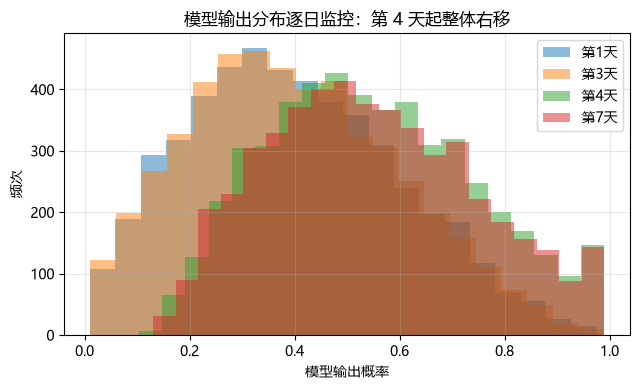

In [3]:
# 模型输出监控：每天记录输出分布，与基线比 PSI
base_prob = np.clip(rng.beta(2, 3, 5000), 0.01, 0.99)   # 基线：上线首周输出分布
days = {}
print("逐日监控（第 4 天起发生漂移）：")
for day in range(1, 8):
    drift = 0.15 if day >= 4 else 0.0
    days[day] = np.clip(base_prob + rng.normal(drift, 0.02, 5000), 0.01, 0.99)
    print(f"第 {day} 天  PSI = {psi(base_prob, days[day]):.3f}  "
          + ("⚠ 超阈值，触发告警" if psi(base_prob, days[day]) > 0.25 else ""))

plt.figure(figsize=(6.5, 4))
for day in [1, 3, 4, 7]:
    plt.hist(days[day], bins=20, alpha=0.5, label=f"第{day}天")
plt.xlabel("模型输出概率"); plt.ylabel("频次")
plt.title("模型输出分布逐日监控：第 4 天起整体右移")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 重训触发策略

| 策略 | 做法 | 优缺点 |
|------|------|--------|
| 定期重训 | 每周/每月固定重训 | 简单，但可能浪费或滞后 |
| 阈值触发 | PSI > 0.25 或线上指标跌破阈值即重训 | 响应快，需监控基建 |
| 滑动窗口 | 窗口内性能/分布异常即触发 | 更精细，工程量大 |
| 混合 | 定期 + 异常触发兜底 | 生产常用 |

**重训不是重新 fit 就完事**：新数据要重新走数据工程 → 评估 → 版本化 → 灰度上线（衔接 06 课的回滚与 A/B）。

In [4]:
# 概念漂移模拟：输入分布没变，输入→输出的规律变了
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Xc, yc = make_classification(n_samples=800, n_features=2, n_informative=2,
                             n_redundant=0, random_state=0)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.5, random_state=0)
m1 = LogisticRegression().fit(Xc_tr, yc_tr)
print("阶段 1（规律正常）准确率 =", round(m1.score(Xc_te, yc_te), 3))

# 概念翻转：同一批样本，标签含义变了（如政策/市场突变）
y_flip = 1 - yc_te
print("概念翻转后同一模型准确率 =", round(m1.score(Xc_te, y_flip), 3), " ← 断崖式下跌")
print("（此时 PSI 可能完全正常——因为特征分布没变！→ 所以输出监控与性能监控缺一不可）")

阶段 1（规律正常）准确率 = 0.892
概念翻转后同一模型准确率 = 0.107  ← 断崖式下跌
（此时 PSI 可能完全正常——因为特征分布没变！→ 所以输出监控与性能监控缺一不可）


## 课后练习

1. **PSI 敏感性练习**：对 `base` 施加 0.5/1/2/5 倍标准差的小扰动，画出"扰动幅度 vs PSI"曲线，找到你的告警阈值设置依据。
2. **Kaggle 关联**：选 Kaggle 任一竞赛的训练集，人为构造数据漂移（对某特征加偏移/换分布），用 PSI 检测并量化——这是"线上数据漂移"的最直观演练。
3. **监控设计练习**：为 06 课的 Titanic 服务设计一个监控方案：监控哪些指标、什么频率、告警阈值、触发后谁做什么（写成一页运维手册）。